# Study A Controllability Analysis

Explicit-control responsiveness against the spontaneous control arm.

## Study Lens

This notebook treats the secondary metric arm as a perturbation of the study's
own endpoint: **diagnostic accuracy and reasoning quality under the arm change**.

Primary plotted metrics: `acc_cot, step_f1`.

Supporting diagnostics: `faithfulness_gap, acc_early`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_UTILS_DIR = Path("benchmark/runtime/notebooks").resolve()
if not NOTEBOOK_UTILS_DIR.exists():
    NOTEBOOK_UTILS_DIR = Path.cwd().resolve()
    while NOTEBOOK_UTILS_DIR.name != "notebooks" and NOTEBOOK_UTILS_DIR.parent != NOTEBOOK_UTILS_DIR:
        NOTEBOOK_UTILS_DIR = NOTEBOOK_UTILS_DIR.parent
if str(NOTEBOOK_UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_UTILS_DIR))

from notebook_utils import (
    find_runtime_root,
    load_reasoning_control_coverage,
    load_reasoning_control_flat,
    load_secondary_coverage,
    load_secondary_flat,
    plot_reasoning_adherence_tiles,
    plot_reasoning_arm_values,
    plot_reasoning_control_delta_ci,
    plot_reasoning_endpoint_scatter,
    plot_reasoning_control_success_bars,
    plot_reasoning_length_control_bars,
    plot_secondary_arm_values,
    plot_secondary_coverage_heatmap,
    plot_secondary_delta_ci,
    plot_secondary_model_heatmap,
    plot_secondary_per_model_heatmaps,
    reasoning_control_headline,
    secondary_metric_headline,
    secondary_missing_table,
    secondary_not_measurable_table,
    secondary_saturation_notes,
    secondary_threshold_audit,
    setup_notebook_style,
)

setup_notebook_style()
runtime_root = find_runtime_root()
metric_root = runtime_root / "metric-results" / "secondary_branch_metrics"
reasoning_root = runtime_root / "metric-results" / "reasoning_control"
study = "study_a"
lanes = ['controllability']
primary_metrics = ['acc_cot', 'step_f1']
context_metrics = ['faithfulness_gap', 'acc_early']
flat_all = load_secondary_flat(metric_root)
coverage_all = load_secondary_coverage(metric_root)
reasoning_all = load_reasoning_control_flat(reasoning_root)
reasoning_coverage_all = load_reasoning_control_coverage(reasoning_root)
df = flat_all[(flat_all["study"] == study) & (flat_all["lane"].isin(lanes))].copy()
coverage = coverage_all[(coverage_all["study"] == study) & (coverage_all["lane"].isin(lanes))].copy()
reasoning_df = reasoning_all[(reasoning_all["study"] == study) & (reasoning_all["lane"].isin(lanes))].copy()
reasoning_coverage = reasoning_coverage_all[(reasoning_coverage_all["study"] == study) & (reasoning_coverage_all["lane"].isin(lanes))].copy()
primary_df = df[df["metric"].isin(primary_metrics)].copy()
context_df = df[df["metric"].isin(context_metrics)].copy()
print("Runtime root:", runtime_root)
print("Rows:", len(df), "Coverage rows:", len(coverage))
print("Reasoning-control rows:", len(reasoning_df), "Coverage rows:", len(reasoning_coverage))
print("Primary study metrics:", ", ".join(primary_metrics))
if context_metrics:
    print("Context diagnostics:", ", ".join(context_metrics))

Runtime root: /Users/ryangichuru/Documents/SSD-K/Uni/3rd year/NLP-ready/benchmark/runtime
Rows: 40 Coverage rows: 6
Reasoning-control rows: 120 Coverage rows: 12
Primary study metrics: acc_cot, step_f1
Context diagnostics: faithfulness_gap, acc_early


## Provenance and coverage

,lane,model,study,status,path,use_nli,nli_stride,nli_device,data_root
0,controllability,deepseek-r1-lmstudio,study_a,missing_cache,NaN,NaN,NaN,NaN,NaN
15,controllability,gpt-oss-20b,study_a,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
5,controllability,piaget-8b-local,study_a,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
20,controllability,psyche-r1-local,study_a,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
25,controllability,psyllm-lmstudio,study_a,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
10,controllability,qwen3-lmstudio,study_a,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...


,lane,model,study,status,path,use_nli,nli_stride,nli_device,data_root
0,controllability,deepseek-r1-lmstudio,study_a,missing_cache,NaN,NaN,NaN,NaN,NaN


,lane,model,study,variant,metric,reason,n_pairs
0,controllability,gpt-oss-20b,study_a,generic_control,acc_early,branch_metric_empty,0
1,controllability,gpt-oss-20b,study_a,explicit_control,acc_early,branch_metric_empty,0
2,controllability,gpt-oss-20b,study_a,generic_control,faithfulness_gap,branch_metric_empty,0
3,controllability,gpt-oss-20b,study_a,explicit_control,faithfulness_gap,branch_metric_empty,0
4,controllability,piaget-8b-local,study_a,generic_control,acc_early,branch_metric_empty,0
5,controllability,piaget-8b-local,study_a,explicit_control,acc_early,branch_metric_empty,0
6,controllability,piaget-8b-local,study_a,generic_control,faithfulness_gap,branch_metric_empty,0
7,controllability,piaget-8b-local,study_a,explicit_control,faithfulness_gap,branch_metric_empty,0
8,controllability,psyche-r1-local,study_a,generic_control,acc_early,branch_metric_empty,0
9,controllability,psyche-r1-local,study_a,explicit_control,acc_early,branch_metric_empty,0


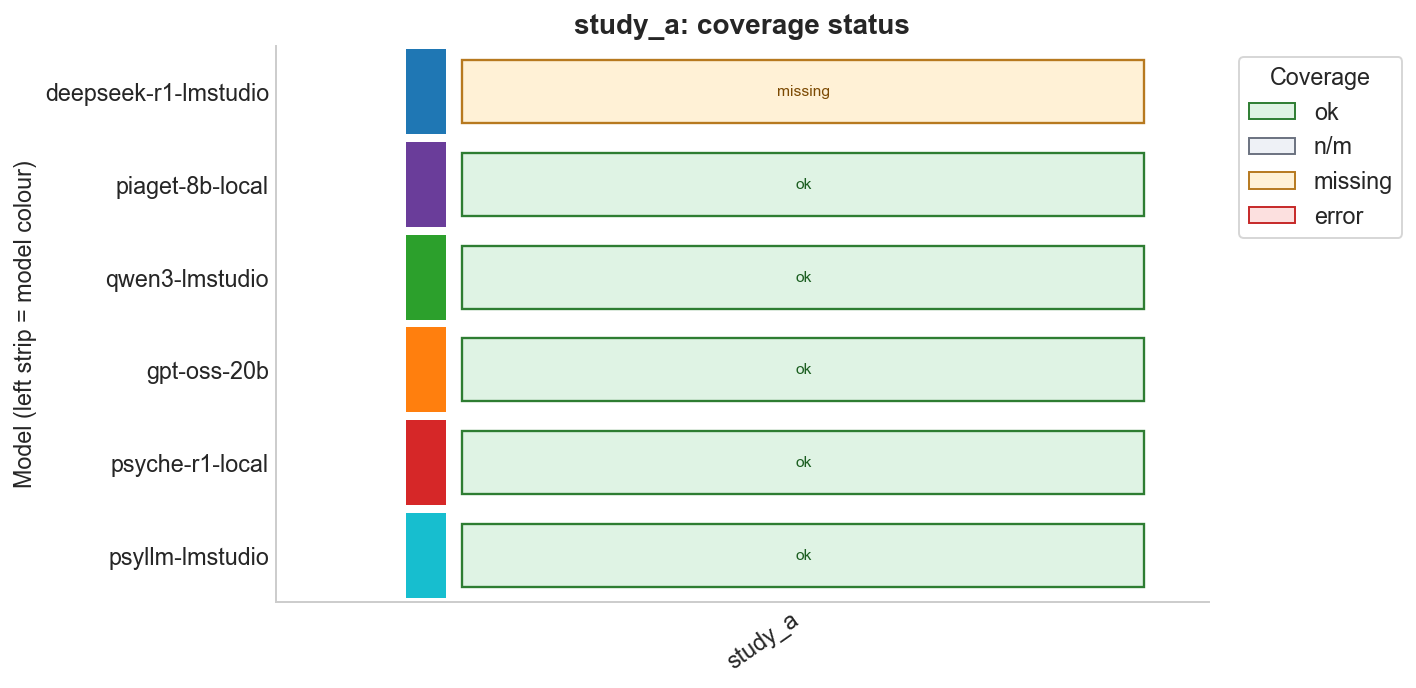

In [2]:
display(coverage.sort_values(["lane", "model", "study"]))
display(secondary_missing_table(coverage))
display(secondary_not_measurable_table(df))
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
plot_secondary_coverage_heatmap(coverage, ax=ax, title=f"{study}: coverage status")
plt.show()

## Metric headline table

In [3]:
headline = secondary_metric_headline(df)
display(headline.round(4))
audit = secondary_threshold_audit(df)
display(audit.round(4))

,lane,study,metric,measured_rows,not_measurable_rows,median_delta,median_abs_delta,max_abs_delta,median_n_pairs,reportable_rows
0,controllability,study_a,acc_cot,10,0,0.0,0.0000,0.0286,294.0,0
3,controllability,study_a,step_f1,10,0,0.0,0.0003,0.0103,294.0,1
1,controllability,study_a,acc_early,0,10,NaN,NaN,NaN,0.0,0
2,controllability,study_a,faithfulness_gap,0,10,NaN,NaN,NaN,0.0,0


,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,controllability,gpt-oss-20b,study_a,generic_control,acc_cot,300,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
1,controllability,gpt-oss-20b,study_a,explicit_control,acc_cot,300,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
2,controllability,piaget-8b-local,study_a,generic_control,acc_cot,296,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
3,controllability,piaget-8b-local,study_a,explicit_control,acc_cot,292,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
4,controllability,psyche-r1-local,study_a,generic_control,acc_cot,140,0.0357,0.0071,-0.0286,-0.0643,0.0000,CI overlaps zero; descriptive only
5,controllability,psyche-r1-local,study_a,explicit_control,acc_cot,140,0.0357,0.0071,-0.0286,-0.0643,0.0071,CI overlaps zero; descriptive only
6,controllability,psyllm-lmstudio,study_a,generic_control,acc_cot,133,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
7,controllability,psyllm-lmstudio,study_a,explicit_control,acc_cot,132,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
8,controllability,qwen3-lmstudio,study_a,generic_control,acc_cot,300,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
9,controllability,qwen3-lmstudio,study_a,explicit_control,acc_cot,300,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only


## Primary study endpoint deltas

,lane,study,metric,measured_rows,not_measurable_rows,median_delta,median_abs_delta,max_abs_delta,median_n_pairs,reportable_rows
0,controllability,study_a,acc_cot,10,0,0.0,0.0000,0.0286,294.0,0
1,controllability,study_a,step_f1,10,0,0.0,0.0003,0.0103,294.0,1


,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,controllability,gpt-oss-20b,study_a,generic_control,acc_cot,300,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
1,controllability,gpt-oss-20b,study_a,explicit_control,acc_cot,300,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
2,controllability,piaget-8b-local,study_a,generic_control,acc_cot,296,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
3,controllability,piaget-8b-local,study_a,explicit_control,acc_cot,292,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
4,controllability,psyche-r1-local,study_a,generic_control,acc_cot,140,0.0357,0.0071,-0.0286,-0.0643,0.0000,CI overlaps zero; descriptive only
5,controllability,psyche-r1-local,study_a,explicit_control,acc_cot,140,0.0357,0.0071,-0.0286,-0.0643,0.0071,CI overlaps zero; descriptive only
6,controllability,psyllm-lmstudio,study_a,generic_control,acc_cot,133,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
7,controllability,psyllm-lmstudio,study_a,explicit_control,acc_cot,132,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
8,controllability,qwen3-lmstudio,study_a,generic_control,acc_cot,300,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
9,controllability,qwen3-lmstudio,study_a,explicit_control,acc_cot,300,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only


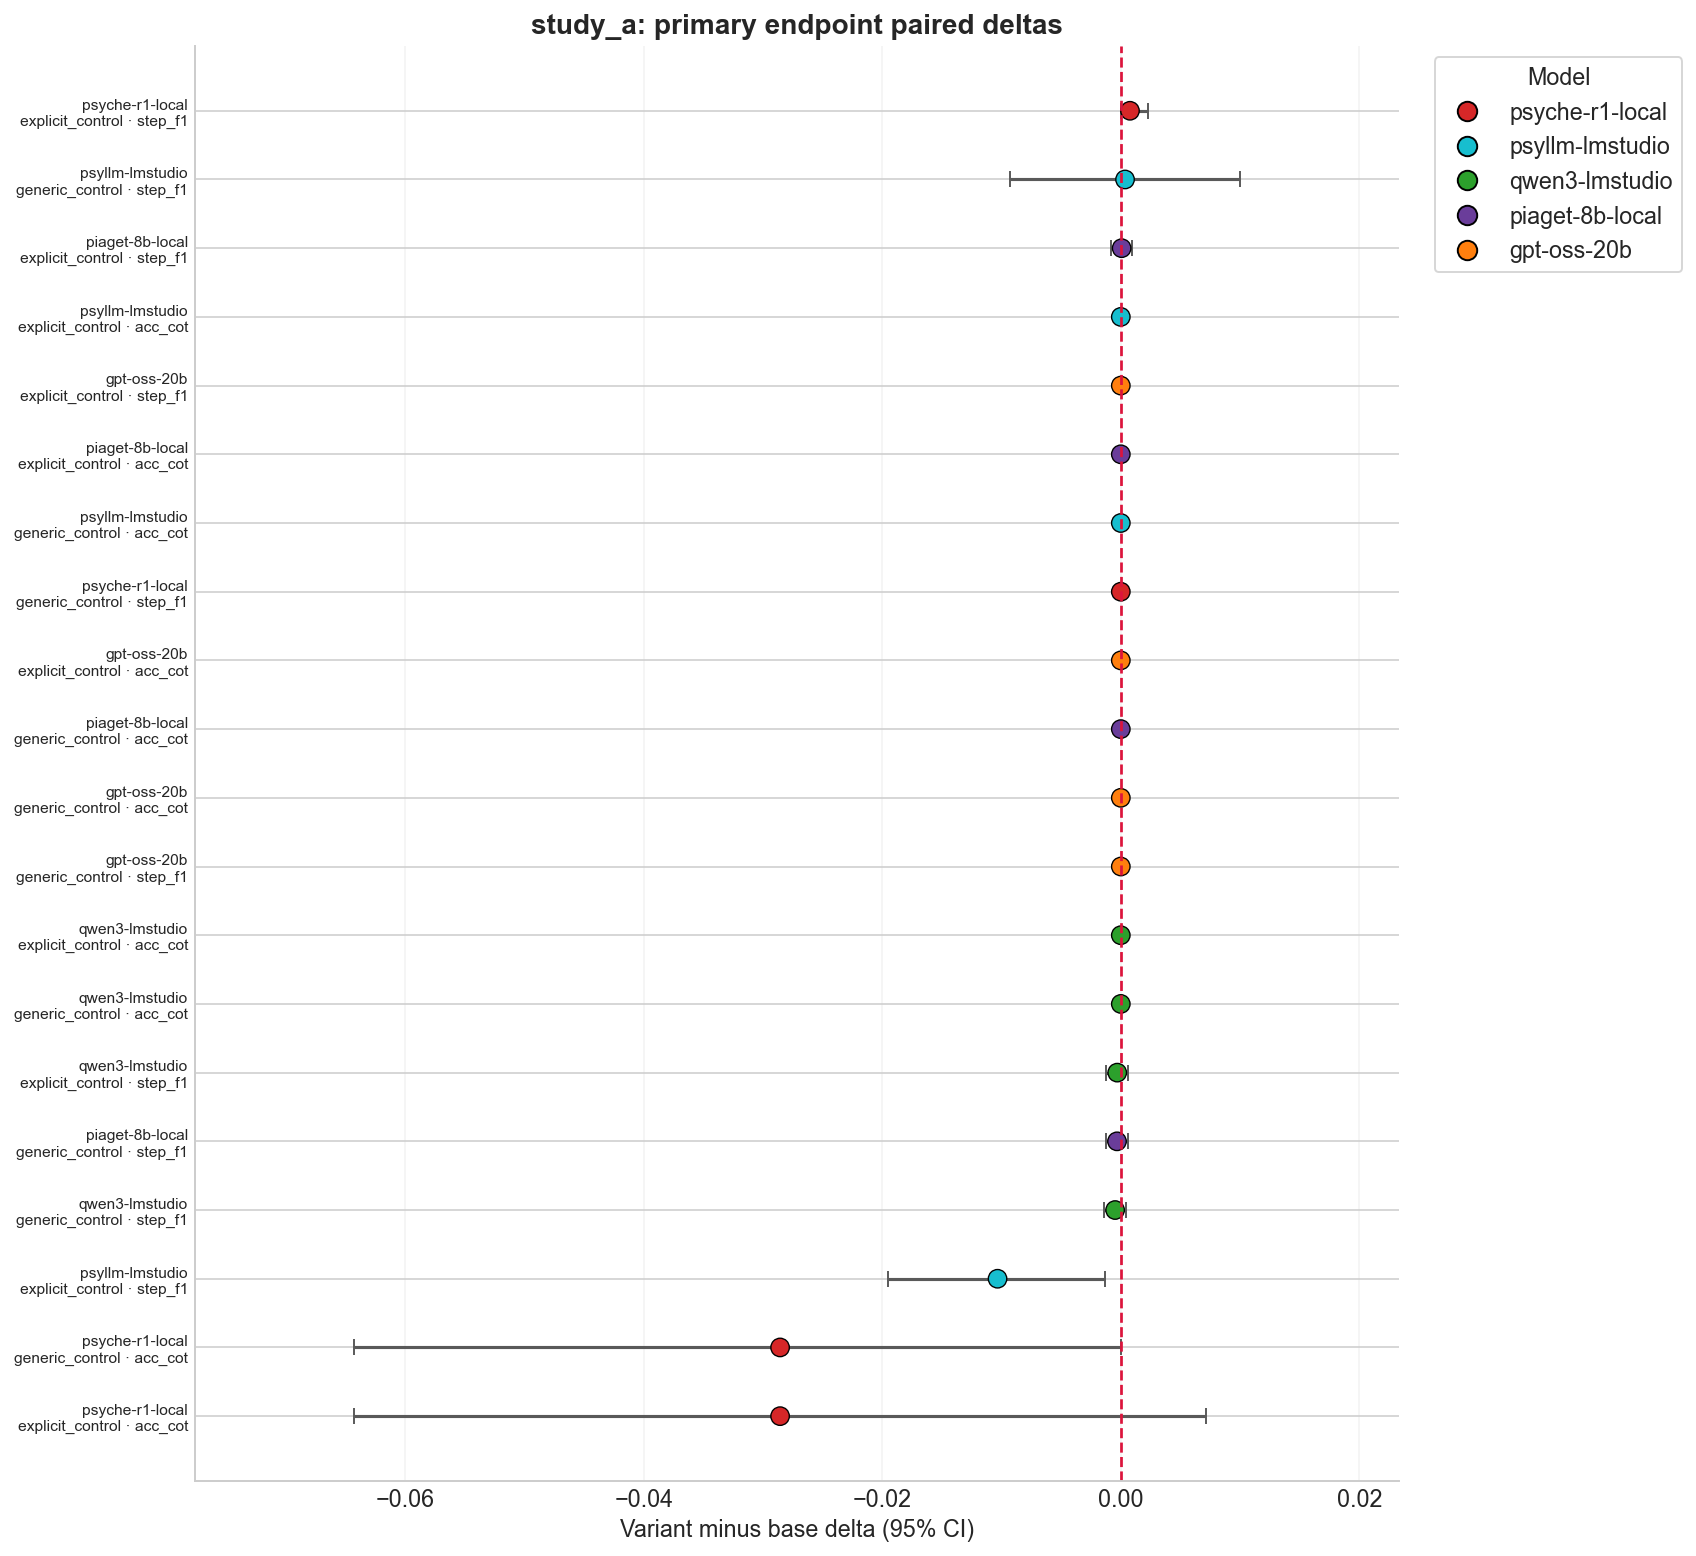

In [4]:
display(secondary_metric_headline(primary_df).round(4))
display(secondary_threshold_audit(primary_df).round(4))
fig, ax = plt.subplots(figsize=(12, max(5, 0.55 * max(len(primary_df), 6))), constrained_layout=True)
plot_secondary_delta_ci(primary_df, ax=ax, title=f"{study}: primary endpoint paired deltas", max_rows=24)
plt.show()

## Primary endpoint base versus variant

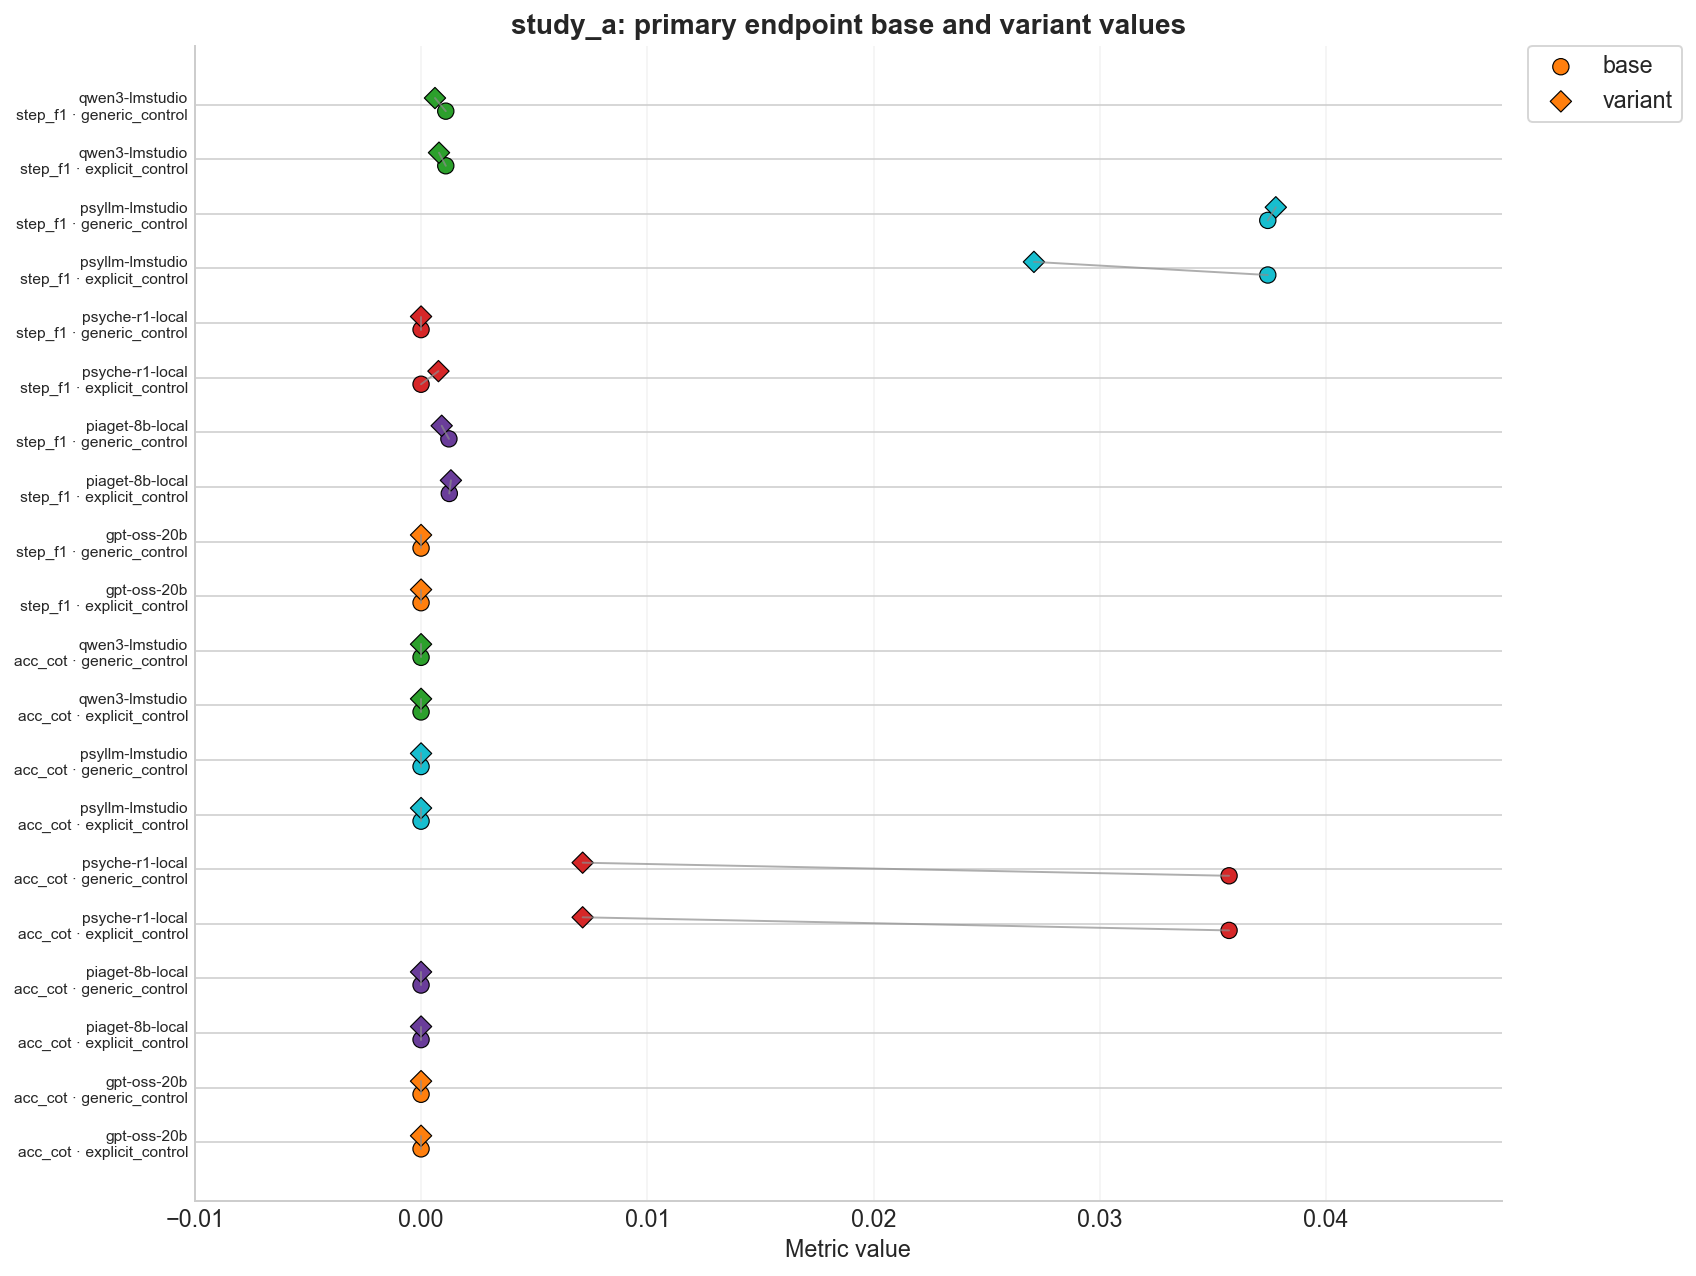

In [5]:
fig, ax = plt.subplots(figsize=(12, max(5, 0.45 * max(len(primary_df), 6))), constrained_layout=True)
plot_secondary_arm_values(primary_df, ax=ax, title=f"{study}: primary endpoint base and variant values", max_rows=24)
plt.show()

## Reasoning and output control

,lane,study,metric,measured_rows,median_delta,median_abs_delta,max_abs_delta,median_n_pairs,ci_excludes_zero
3,controllability,study_a,output_tokens,6,-14.6150,44.4100,369.7367,300.0,4
7,controllability,study_a,visible_reasoning_tokens,6,-63.6000,63.6000,152.5867,300.0,6
0,controllability,study_a,final_answer_marker_present,6,0.2150,0.2150,0.3033,300.0,6
2,controllability,study_a,output_control_success_proxy,6,0.2150,0.2150,0.3033,300.0,5
6,controllability,study_a,reasoning_share,6,0.0353,0.0463,0.1211,300.0,6
1,controllability,study_a,meta_discussion_present,6,-0.0367,0.0617,0.0767,300.0,4
4,controllability,study_a,reasoning_control_success_proxy,6,0.0000,0.0000,0.0200,300.0,1
5,controllability,study_a,reasoning_marker_present,6,0.0000,0.0000,0.0200,300.0,1


,lane,study,model,variant,metric,status,reason,n_pairs,base_value,variant_value,delta,median_delta,ci_low,ci_high,endpoint_delta_median_abs,base_cache,variant_cache
19,controllability,study_a,deepseek-r1-lmstudio,explicit_control,control_adherence_without_meta_discussion,missing_cache,missing_cache,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,controllability,study_a,deepseek-r1-lmstudio,explicit_control,control_phrase_adherence,missing_cache,missing_cache,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,controllability,study_a,deepseek-r1-lmstudio,explicit_control,final_answer_marker_present,missing_cache,missing_cache,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,controllability,study_a,deepseek-r1-lmstudio,explicit_control,meta_discussion_present,missing_cache,missing_cache,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,controllability,study_a,deepseek-r1-lmstudio,explicit_control,output_control_success_proxy,missing_cache,missing_cache,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500,controllability,study_a,psyllm-lmstudio,generic_control,visible_reasoning_tokens,missing_cache,missing_cache,0,NaN,NaN,NaN,NaN,NaN,NaN,0.000177,NaN,NaN
219,controllability,study_a,qwen3-lmstudio,explicit_control,control_adherence_without_meta_discussion,not_measurable,metric_not_applicable,0,NaN,NaN,NaN,NaN,NaN,NaN,0.000150,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
215,controllability,study_a,qwen3-lmstudio,explicit_control,control_phrase_adherence,not_measurable,no_control_prompt_rule,0,NaN,NaN,NaN,NaN,NaN,NaN,0.000150,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
209,controllability,study_a,qwen3-lmstudio,generic_control,control_adherence_without_meta_discussion,not_measurable,metric_not_applicable,0,NaN,NaN,NaN,NaN,NaN,NaN,0.000239,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...


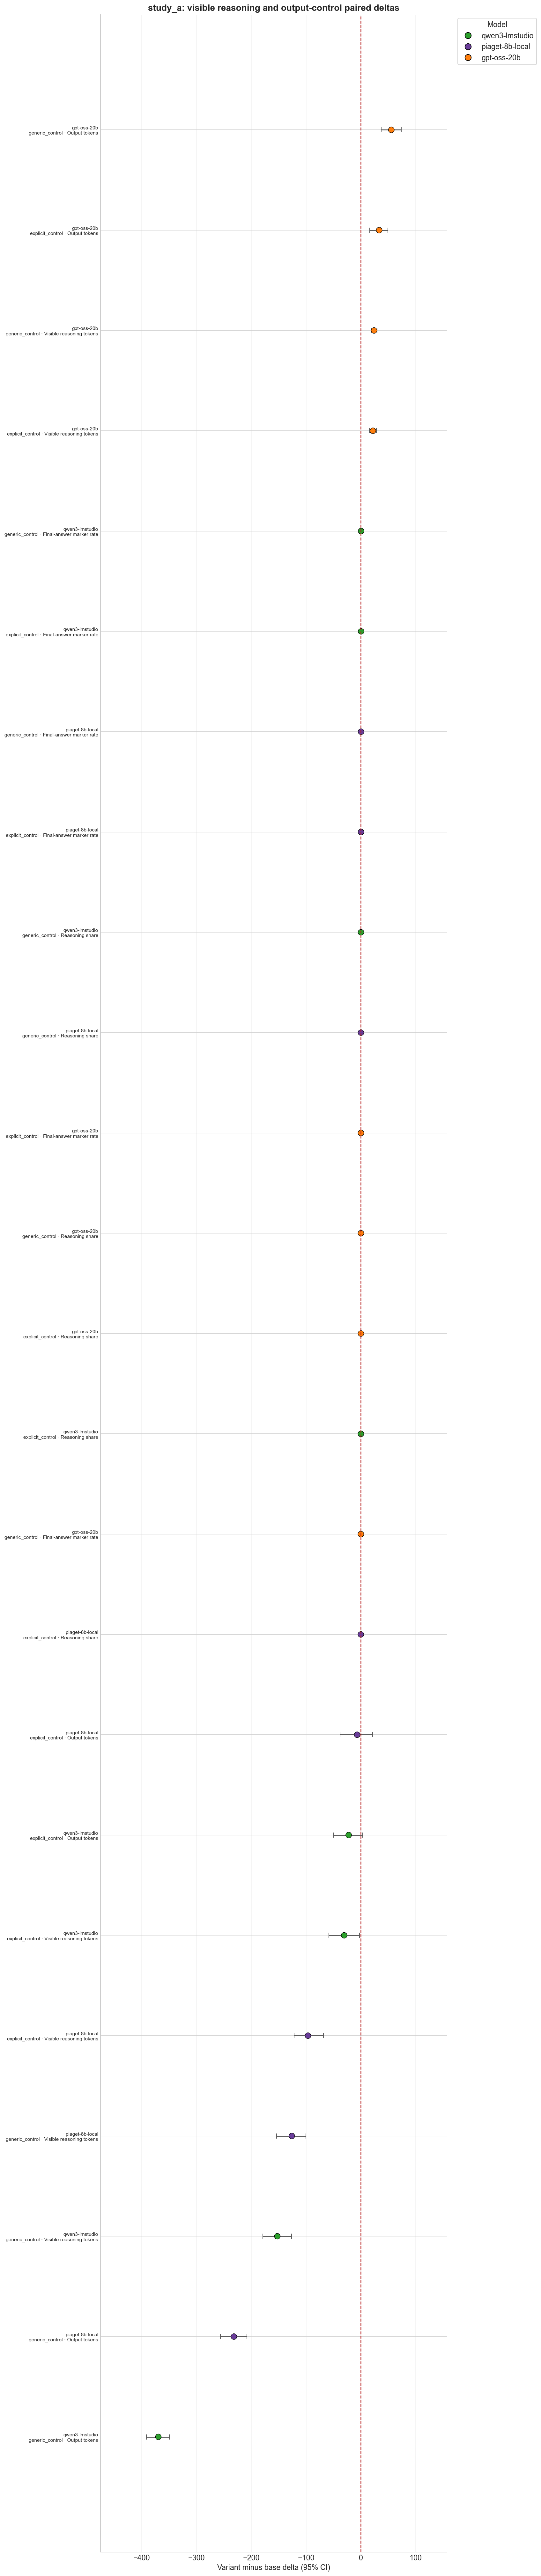

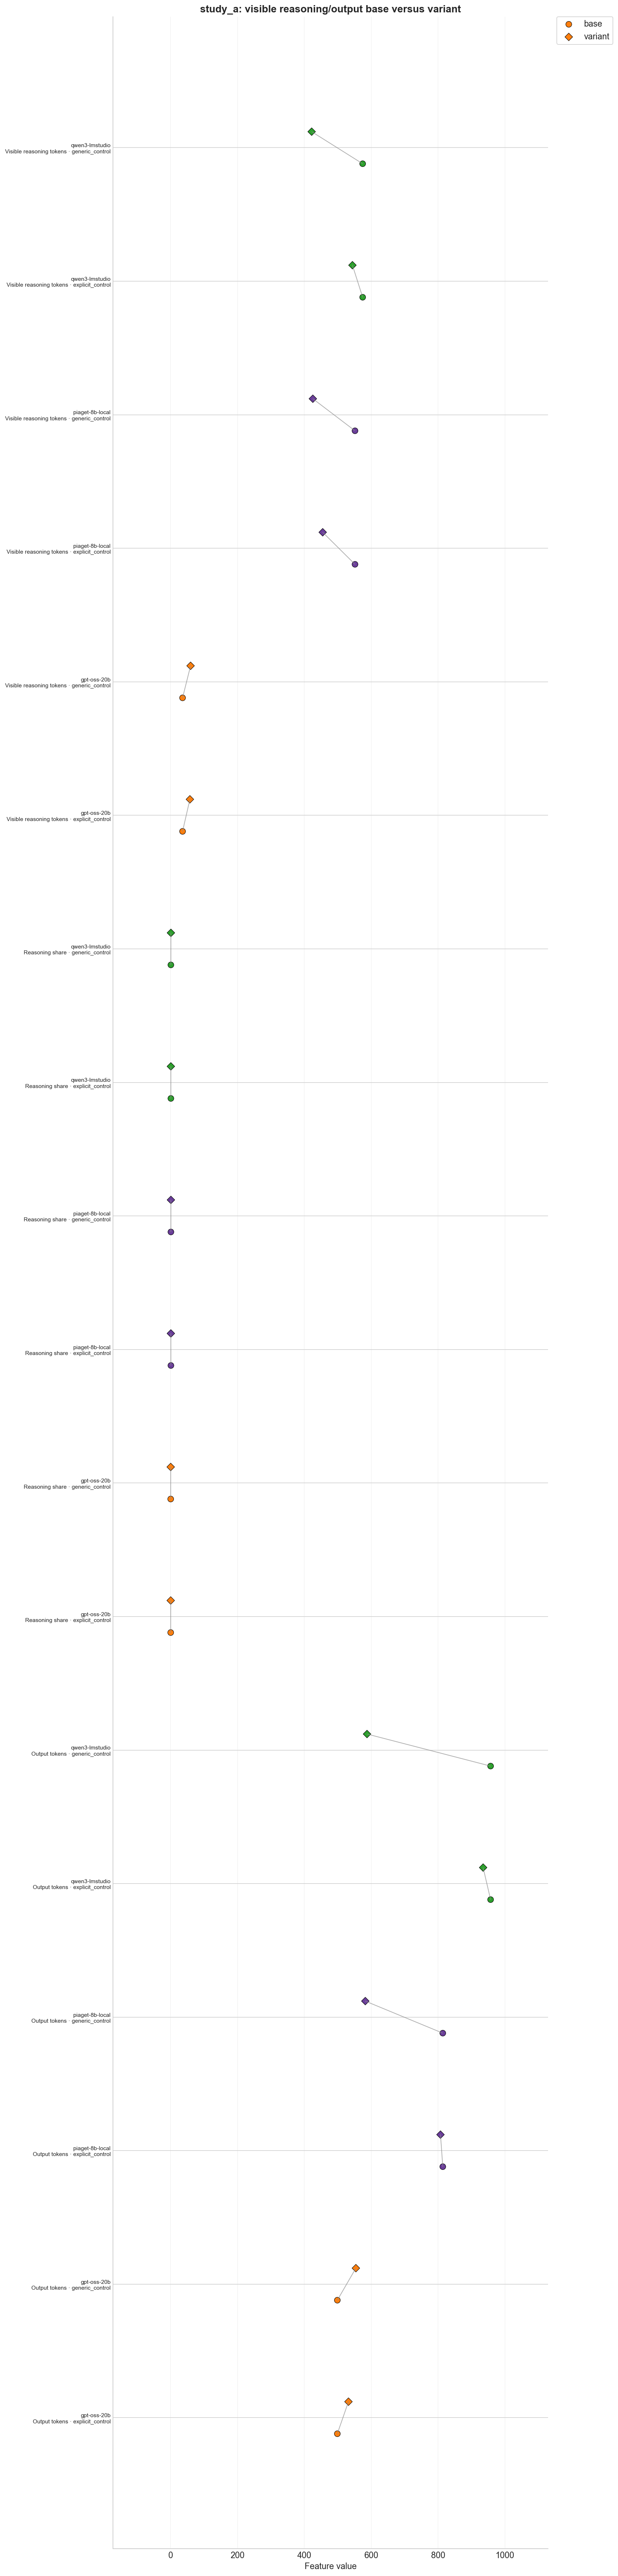

In [6]:
display(reasoning_control_headline(reasoning_df).round(4))
display(reasoning_df[reasoning_df["status"].fillna("") != "ok"].sort_values(["lane", "model", "variant", "metric"]))

fig, ax = plt.subplots(figsize=(12, max(5, 0.48 * max(len(reasoning_df), 8))), constrained_layout=True)
plot_reasoning_control_delta_ci(
    reasoning_df,
    ax=ax,
    title=f"{study}: visible reasoning and output-control paired deltas",
    metrics=["visible_reasoning_tokens", "output_tokens", "reasoning_share", "final_answer_marker_present"],
    max_rows=26,
)
plt.show()

fig, ax = plt.subplots(figsize=(12, max(5, 0.42 * max(len(reasoning_df), 8))), constrained_layout=True)
plot_reasoning_arm_values(
    reasoning_df,
    ax=ax,
    title=f"{study}: visible reasoning/output base versus variant",
    metrics=["visible_reasoning_tokens", "output_tokens", "reasoning_share"],
    max_rows=22,
)
plt.show()

## CoT-Control-style proxy bars

The CoT-Control paper reports controllability as success-rate bars: reasoning
control, output control, and stricter variants that exclude meta-discussion.
These panels adapt that reporting style to the fields available here. They are
proxy diagnostics over visible response text, not hidden CoT-token telemetry.

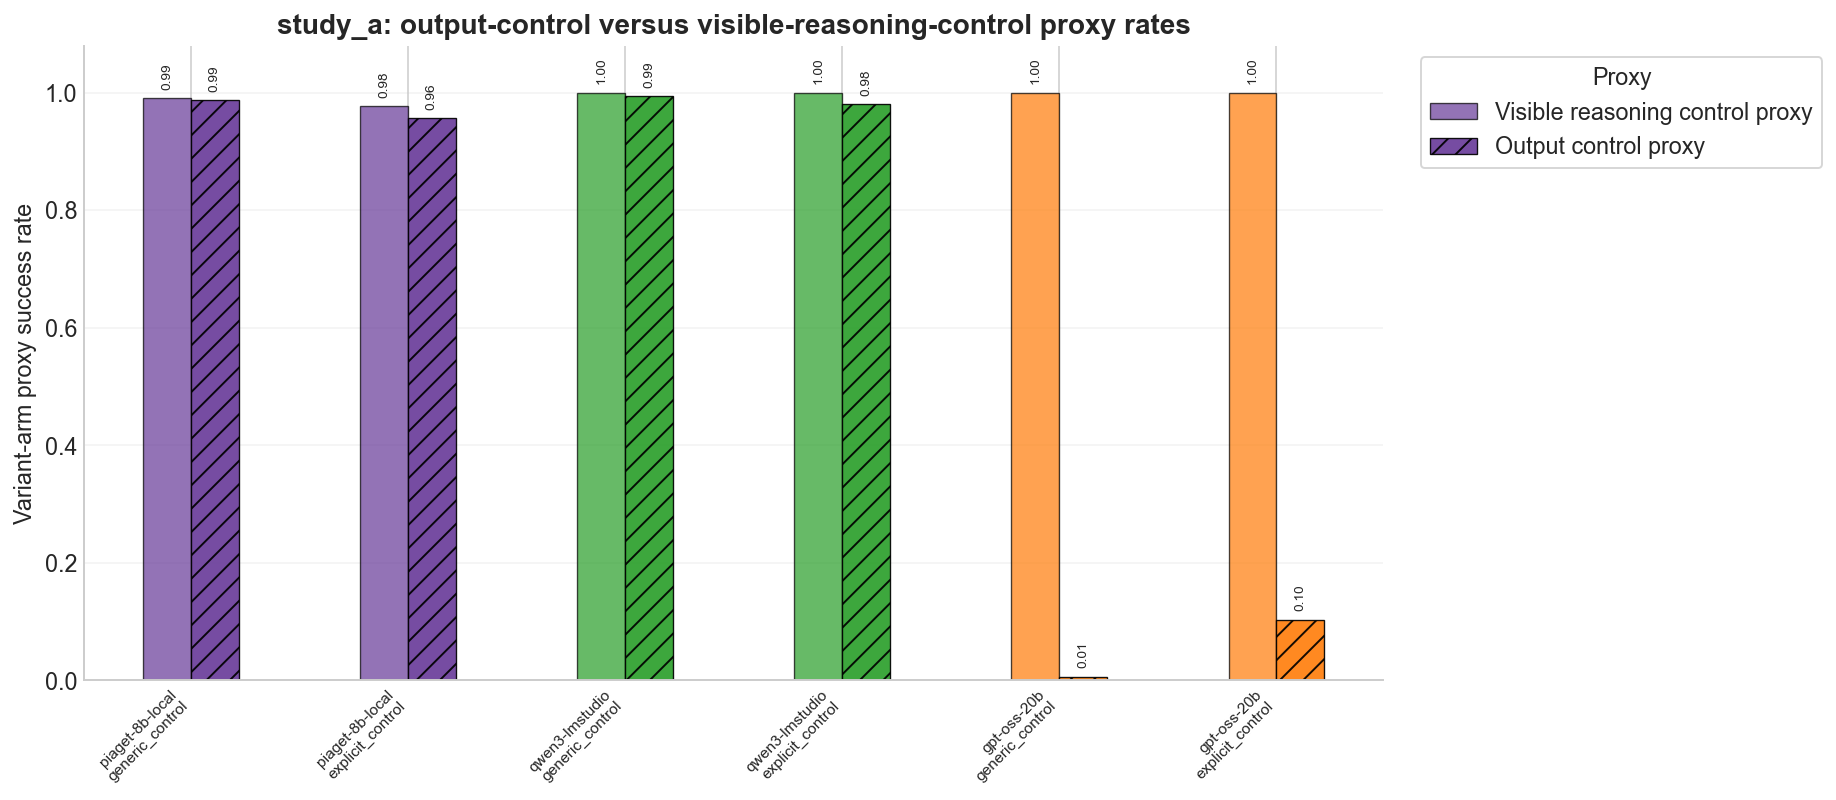

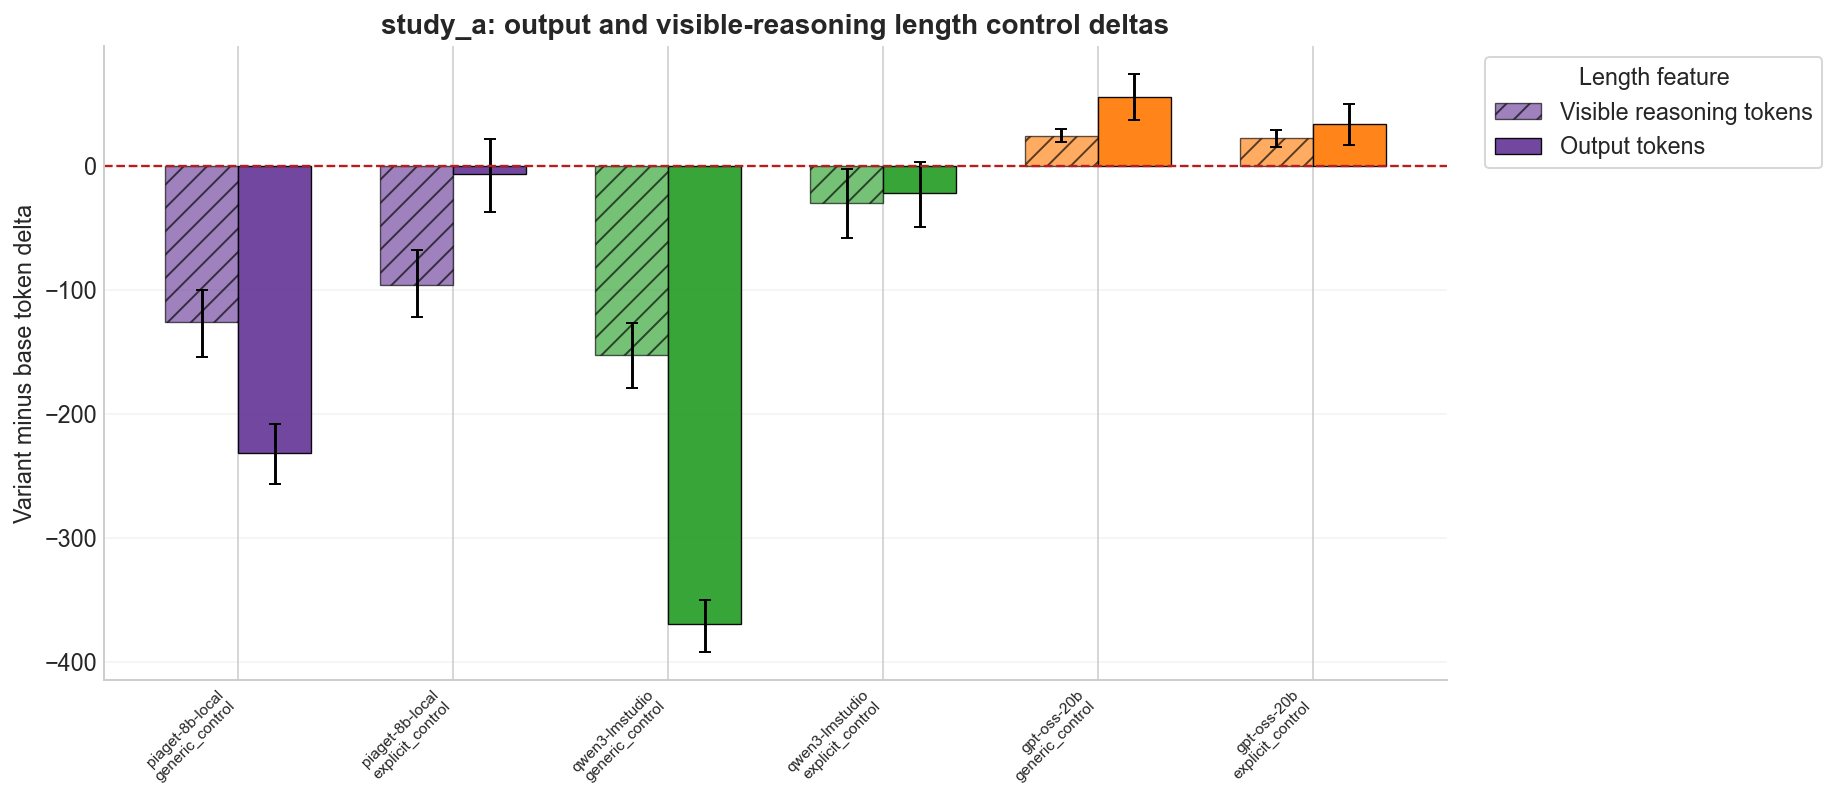

In [7]:
fig, ax = plt.subplots(figsize=(13, 5.6), constrained_layout=True)
plot_reasoning_control_success_bars(
    reasoning_df,
    ax=ax,
    title=f"{study}: output-control versus visible-reasoning-control proxy rates",
)
plt.show()

fig, ax = plt.subplots(figsize=(13, 5.6), constrained_layout=True)
plot_reasoning_length_control_bars(
    reasoning_df,
    ax=ax,
    title=f"{study}: output and visible-reasoning length control deltas",
)
plt.show()

## Marker and control-adherence audit

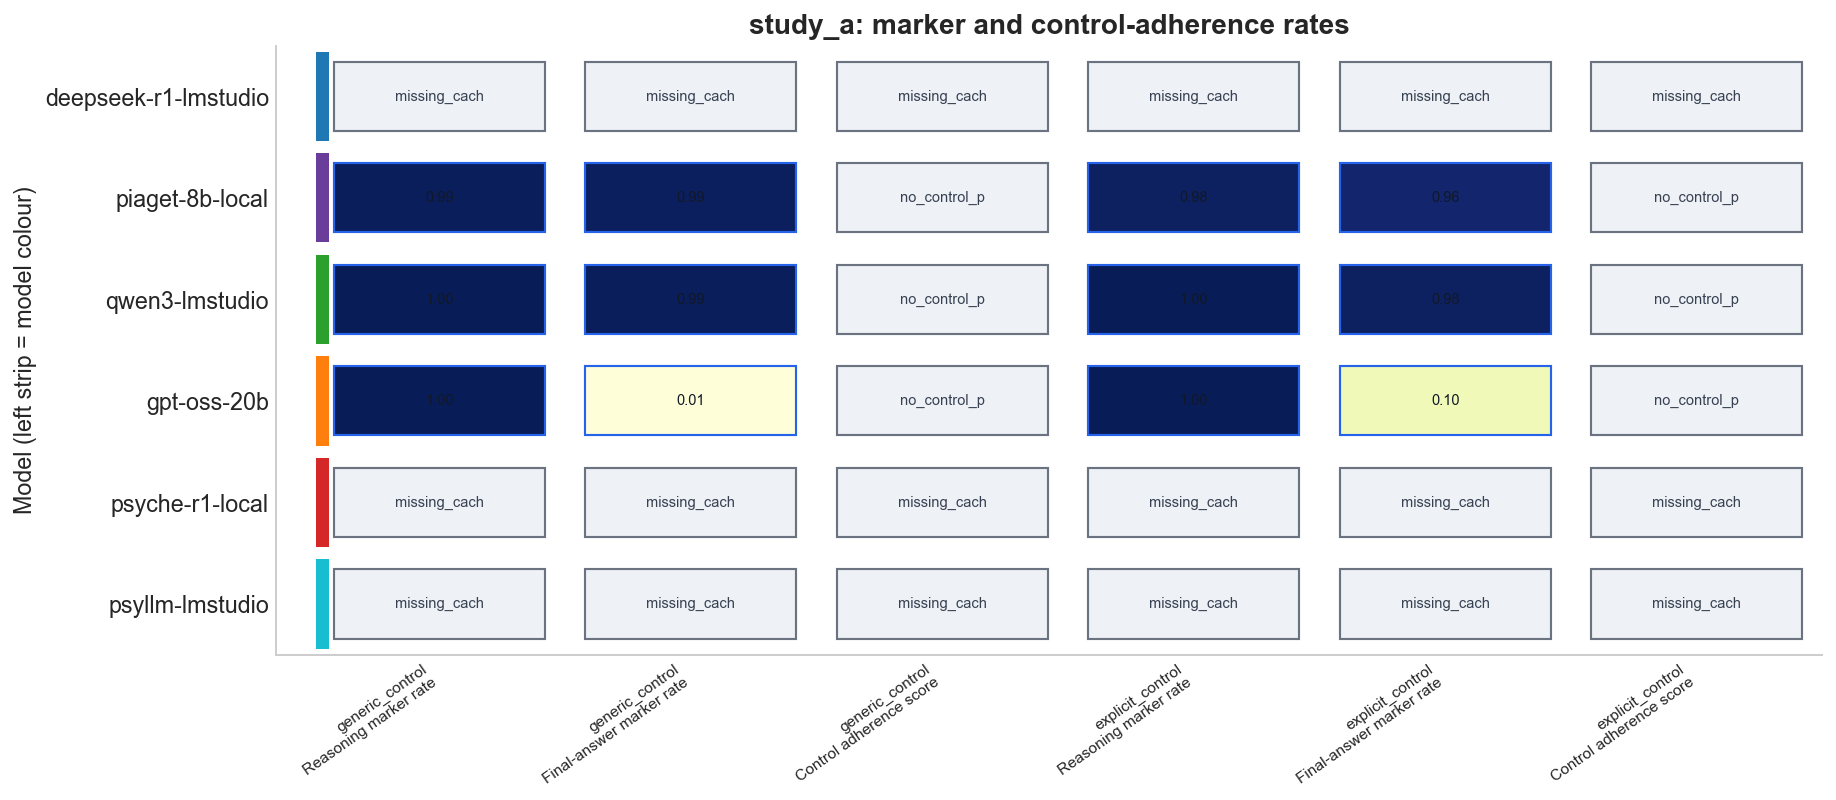

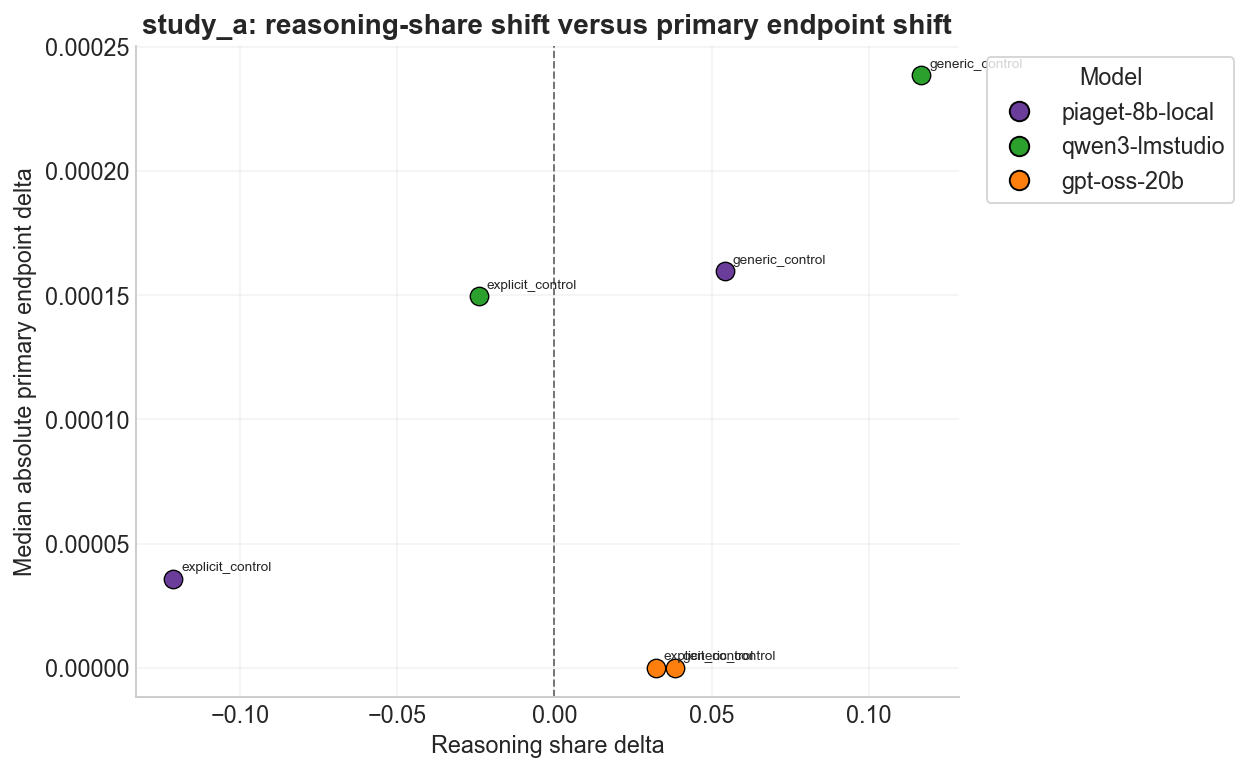

In [8]:
fig, ax = plt.subplots(figsize=(13, 5.6), constrained_layout=True)
plot_reasoning_adherence_tiles(reasoning_df, ax=ax, title=f"{study}: marker and control-adherence rates")
plt.show()

fig, ax = plt.subplots(figsize=(8.8, 5.4), constrained_layout=True)
plot_reasoning_endpoint_scatter(
    reasoning_df,
    ax=ax,
    title=f"{study}: reasoning-share shift versus primary endpoint shift",
    metric="reasoning_share",
)
plt.show()

## Baseline and saturation notes

In [9]:
saturation = secondary_saturation_notes(primary_df, coverage)
if saturation.empty:
    print("No measured ceiling/floor saturation rows detected for the primary endpoint metrics.")
else:
    display(saturation.round(4))

if study == "study_c" and "controllability" in lanes:
    measured_models = sorted(coverage.loc[coverage["status"].fillna("") == "ok", "model"].unique())
    missing_models = sorted(coverage.loc[coverage["status"].fillna("") != "ok", "model"].unique())
    print("Study C controllability note:")
    print("Measured models:", ", ".join(measured_models) if measured_models else "none")
    print("Missing-cache models:", ", ".join(missing_models) if missing_models else "none")
    print(
        "Interpret neutral Study C deltas as ceiling/floor behaviour on the measurable subset "
        "when recall is saturated at 1.0 or conflict is saturated at 0.0; do not overclaim broad robustness."
    )

,lane,study,model,variant,metric,base_value,variant_value,delta,n_pairs,note
0,controllability,study_a,gpt-oss-20b,generic_control,acc_cot,0.0,0.0,0.0,300,Measured floor: base and variant are both 0.0
1,controllability,study_a,gpt-oss-20b,explicit_control,acc_cot,0.0,0.0,0.0,300,Measured floor: base and variant are both 0.0
2,controllability,study_a,piaget-8b-local,generic_control,acc_cot,0.0,0.0,0.0,296,Measured floor: base and variant are both 0.0
3,controllability,study_a,piaget-8b-local,explicit_control,acc_cot,0.0,0.0,0.0,292,Measured floor: base and variant are both 0.0
4,controllability,study_a,psyllm-lmstudio,generic_control,acc_cot,0.0,0.0,0.0,133,Measured floor: base and variant are both 0.0
5,controllability,study_a,psyllm-lmstudio,explicit_control,acc_cot,0.0,0.0,0.0,132,Measured floor: base and variant are both 0.0
6,controllability,study_a,qwen3-lmstudio,generic_control,acc_cot,0.0,0.0,0.0,300,Measured floor: base and variant are both 0.0
7,controllability,study_a,qwen3-lmstudio,explicit_control,acc_cot,0.0,0.0,0.0,300,Measured floor: base and variant are both 0.0
8,controllability,study_a,gpt-oss-20b,generic_control,step_f1,0.0,0.0,0.0,300,Measured floor: base and variant are both 0.0
9,controllability,study_a,gpt-oss-20b,explicit_control,step_f1,0.0,0.0,0.0,300,Measured floor: base and variant are both 0.0


## Threshold framing

Use thresholds as an equivalence/safety audit, not as post-hoc decoration.
For invariance, a model is safer on a measured endpoint only if the full 95% CI
for the paired delta stays inside a pre-declared negligible-change margin around
zero. For controllability, require both intended-control evidence
(for example adherence/output-structure floor) and endpoint preservation
(primary clinical endpoint delta within its equivalence margin). Saturated
rows such as `1.0 -> 1.0` recall or `0.0 -> 0.0` conflict are measured
ceiling/floor results, not missing data, but they should be reported as
saturation rather than broad robustness.

## Paired-delta confidence intervals

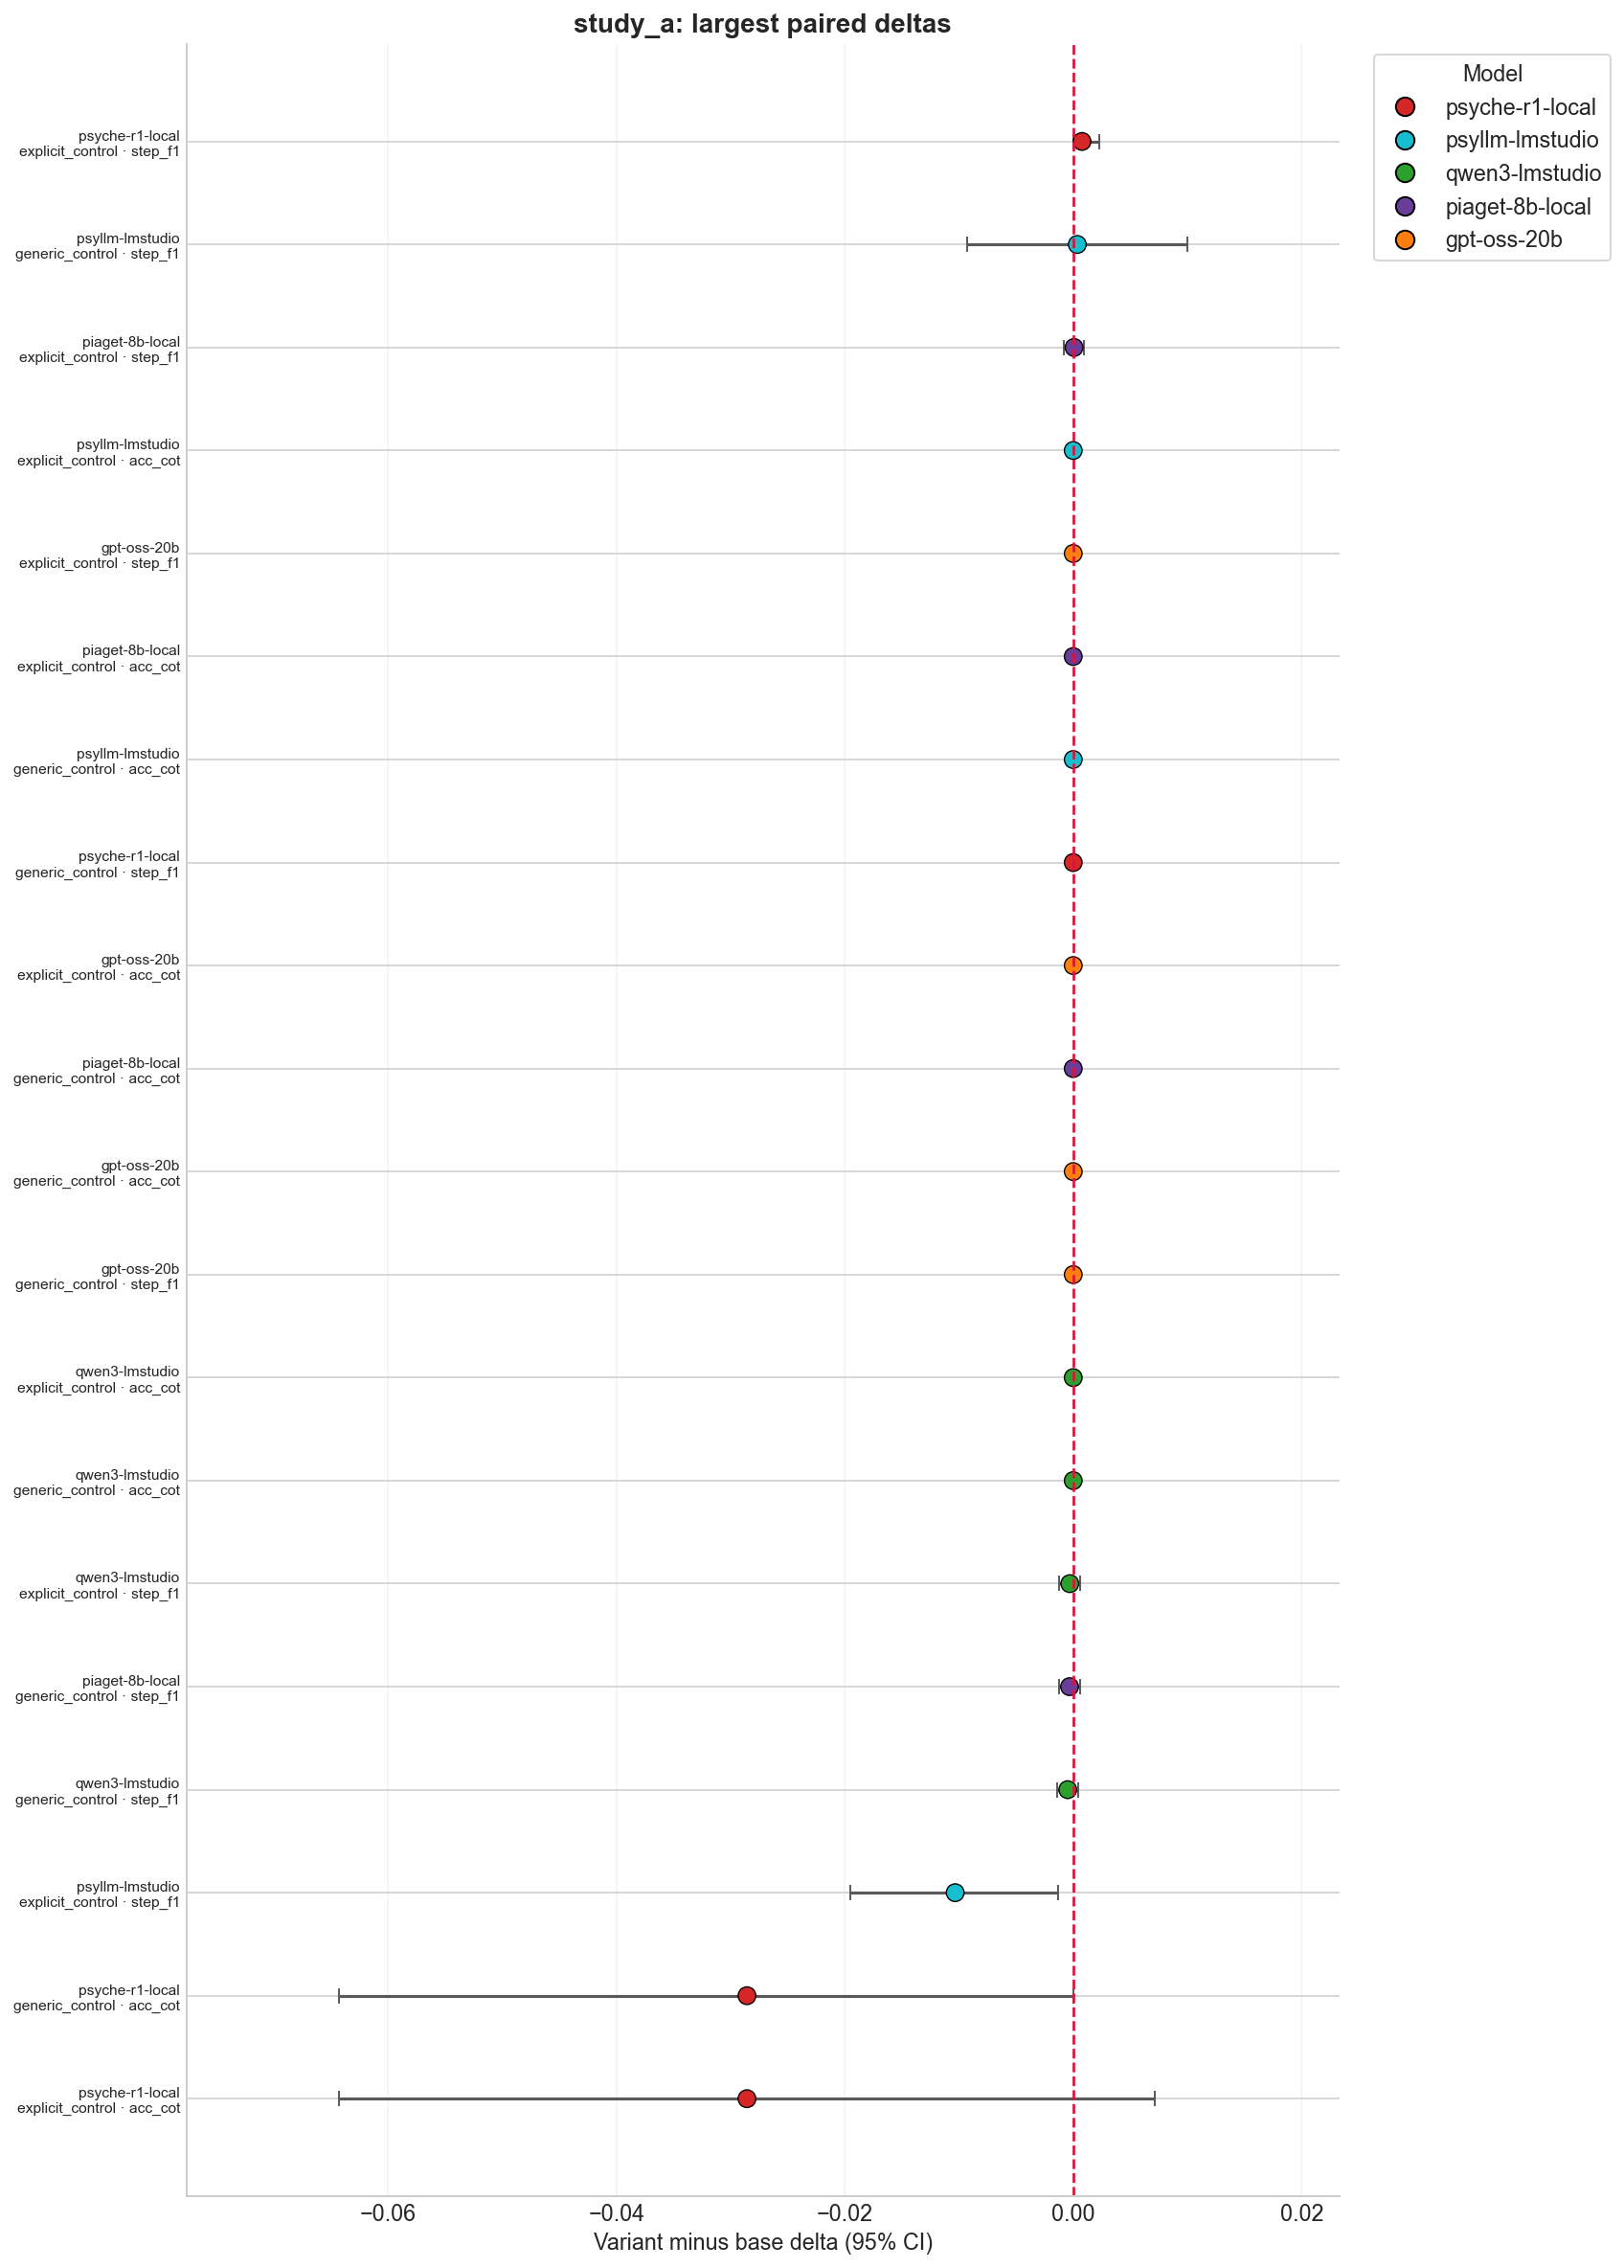

In [10]:
fig, ax = plt.subplots(figsize=(12, max(5, 0.42 * max(len(df), 8))), constrained_layout=True)
plot_secondary_delta_ci(df, ax=ax, title=f"{study}: largest paired deltas", max_rows=30)
plt.show()

## Base versus variant values

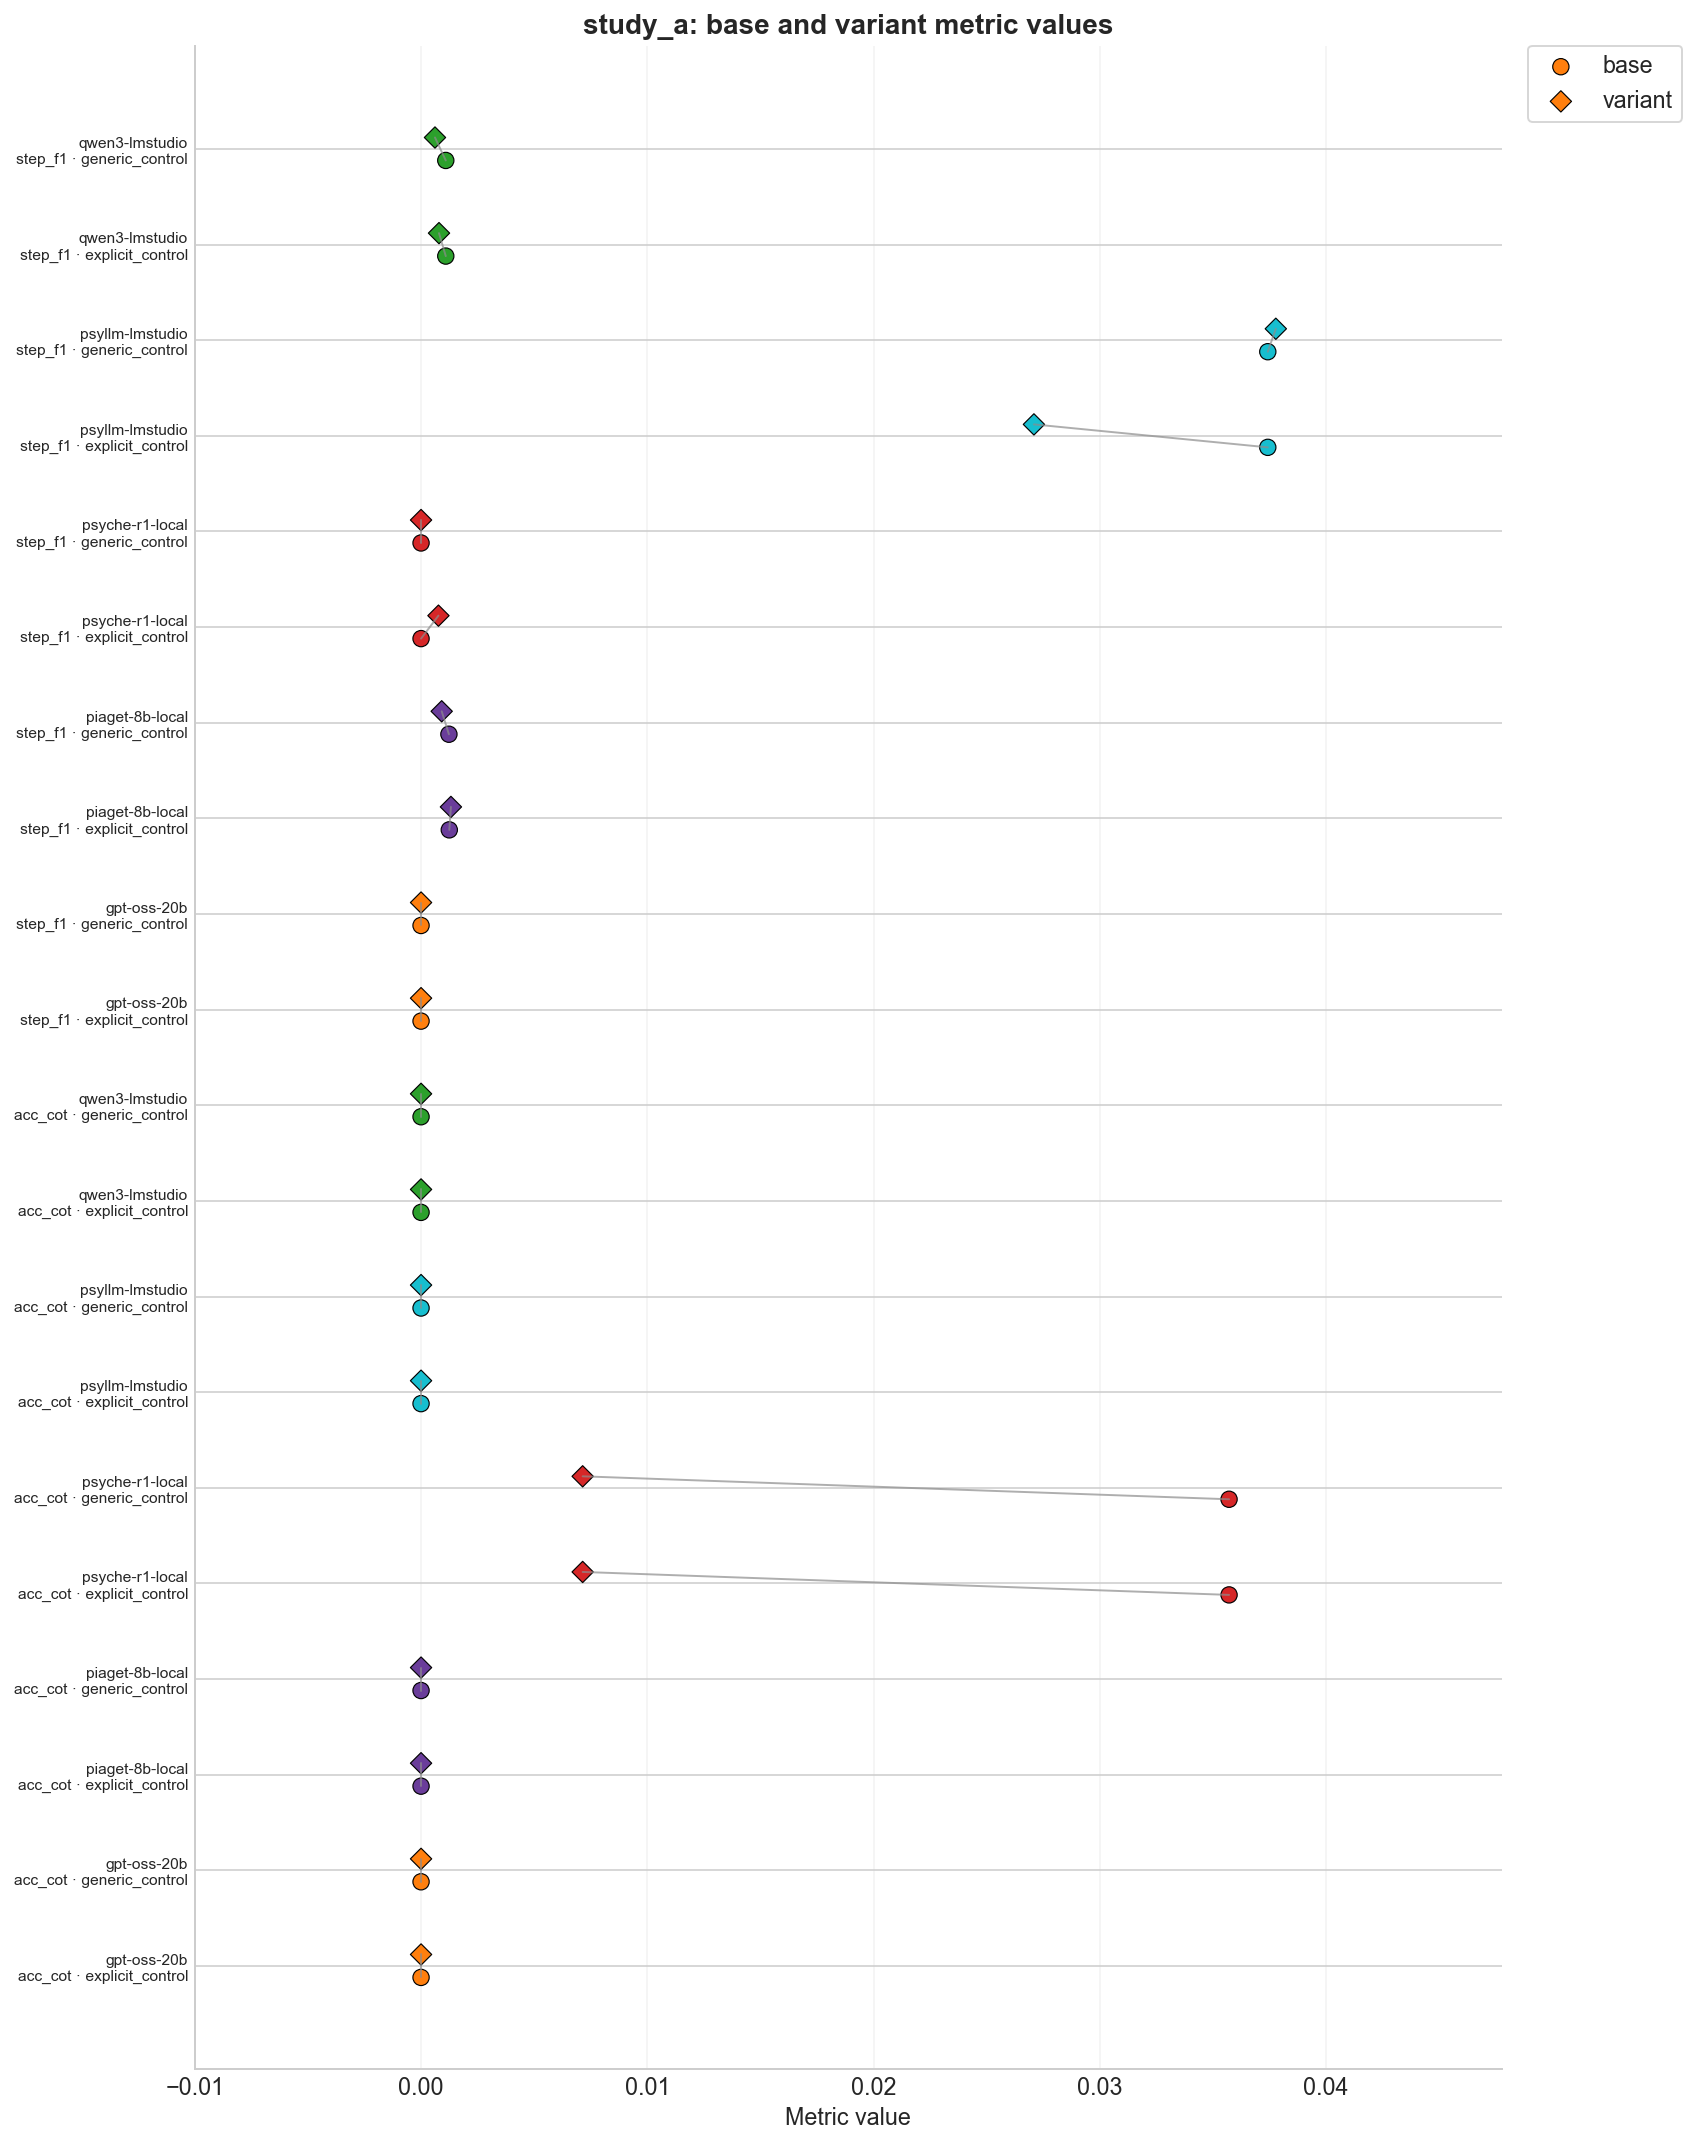

In [11]:
fig, ax = plt.subplots(figsize=(12, max(5, 0.38 * max(len(df), 8))), constrained_layout=True)
plot_secondary_arm_values(df, ax=ax, title=f"{study}: base and variant metric values", max_rows=28)
plt.show()

## Model sensitivity heatmap

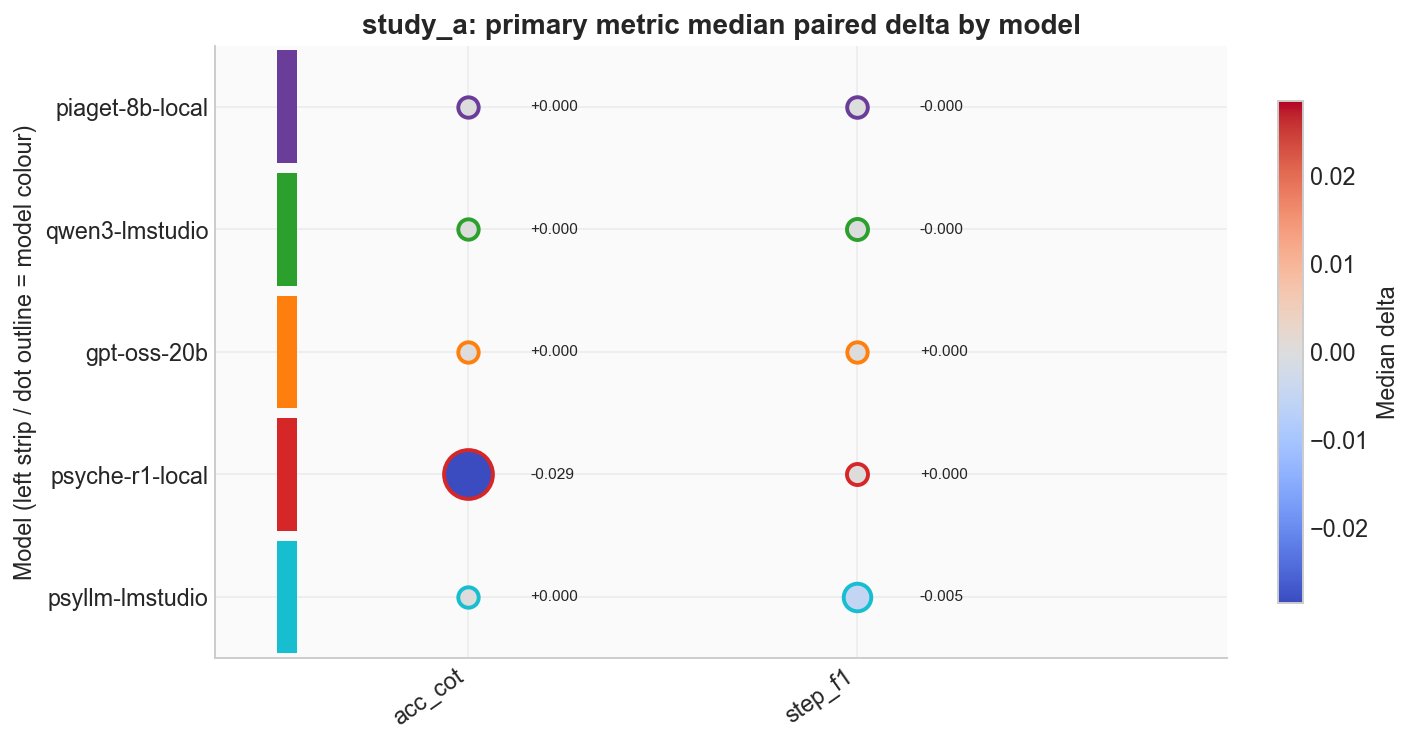

In [12]:
fig, ax = plt.subplots(figsize=(10, 5.2), constrained_layout=True)
plot_secondary_model_heatmap(primary_df, ax=ax, title=f"{study}: primary metric median paired delta by model")
plt.show()

## Model-separated metric heatmaps

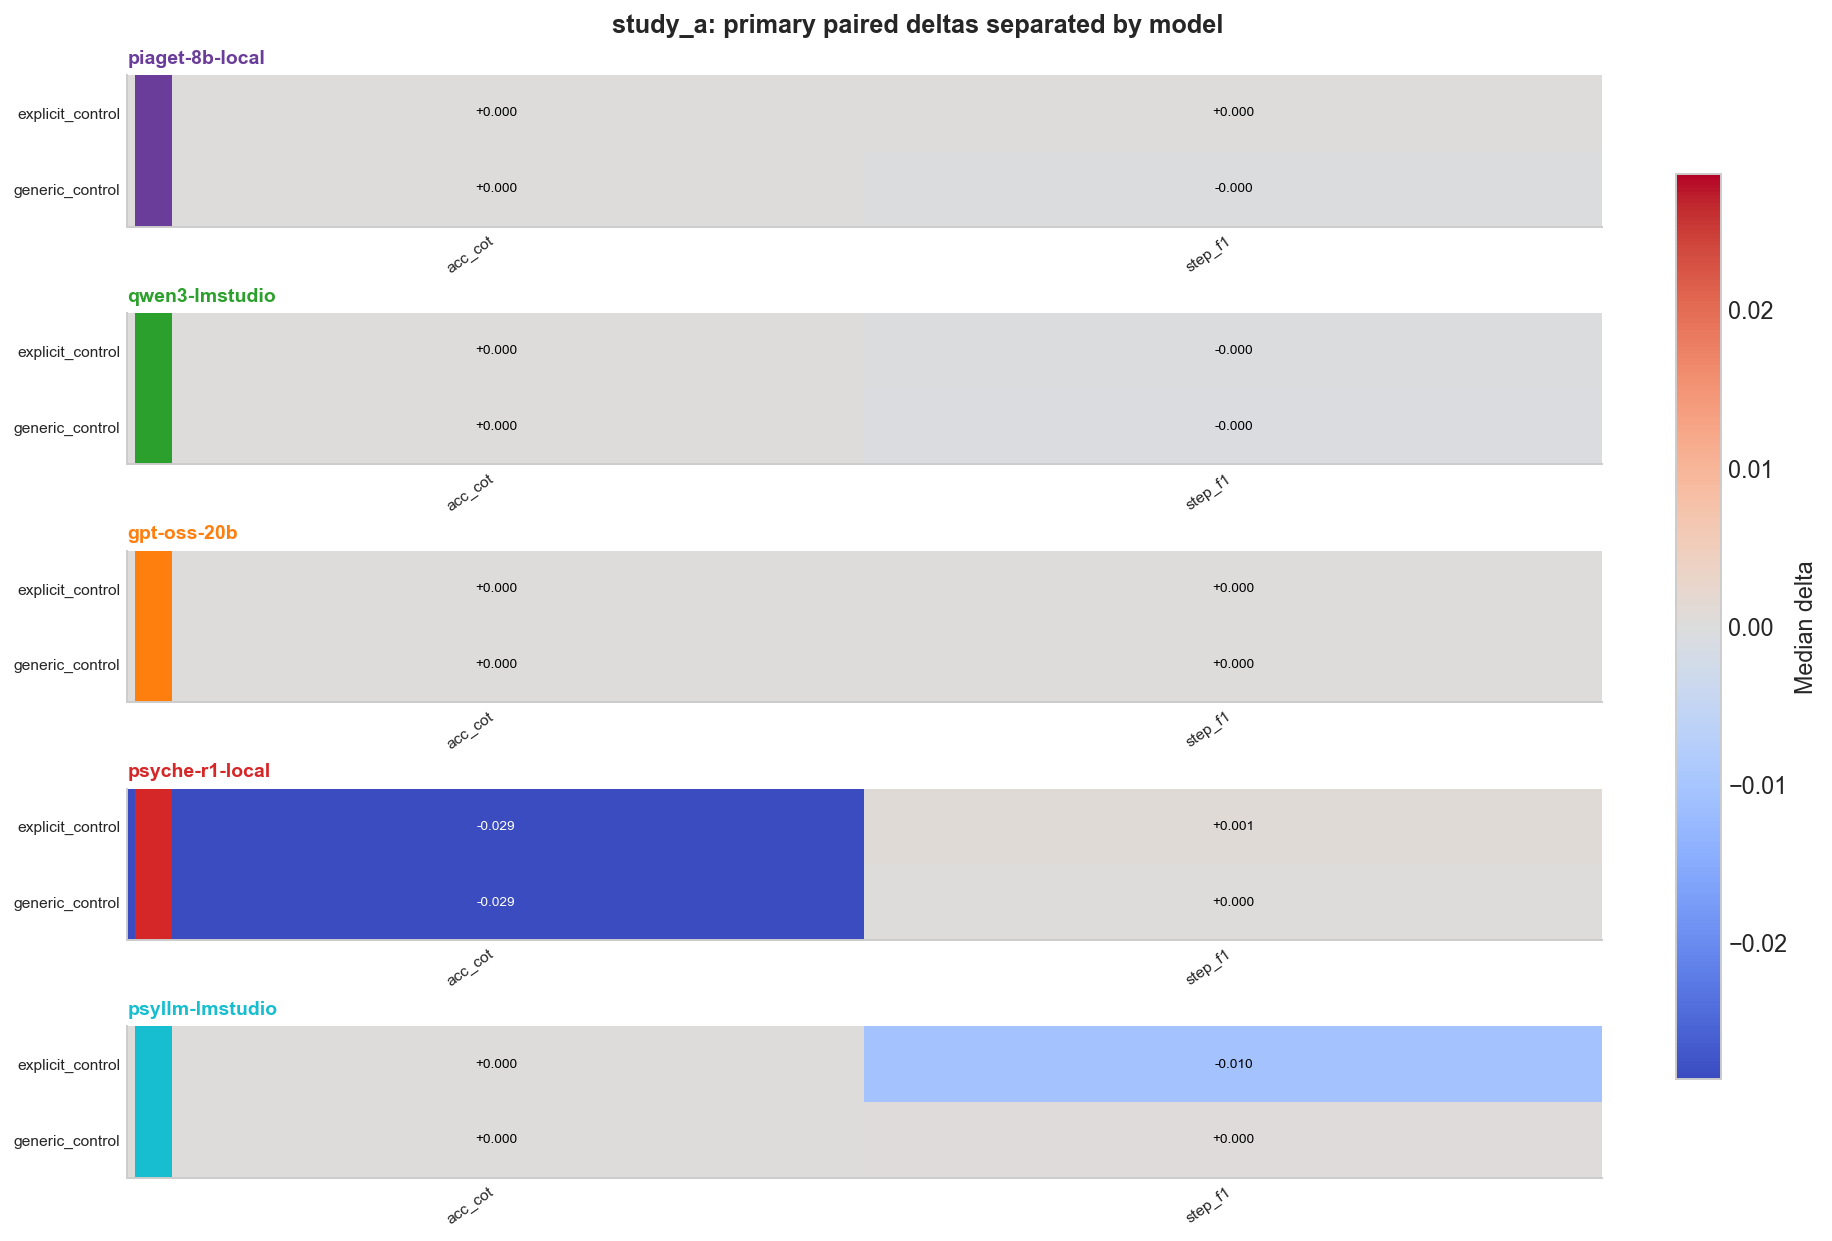

In [13]:
models_with_rows = sorted(primary_df.loc[(primary_df["status"] == "ok") & primary_df["delta"].notna(), "model"].unique())
height = max(4.5, 1.75 * max(len(models_with_rows), 1))
fig, axes = plt.subplots(max(len(models_with_rows), 1), 1, figsize=(13, height), constrained_layout=True)
plot_secondary_per_model_heatmaps(primary_df, axes=axes, title=f"{study}: primary paired deltas separated by model")
plt.show()

## Supporting diagnostics

,lane,study,metric,measured_rows,not_measurable_rows,median_delta,median_abs_delta,max_abs_delta,median_n_pairs,reportable_rows
0,controllability,study_a,acc_early,0,10,NaN,NaN,NaN,0.0,0
1,controllability,study_a,faithfulness_gap,0,10,NaN,NaN,NaN,0.0,0


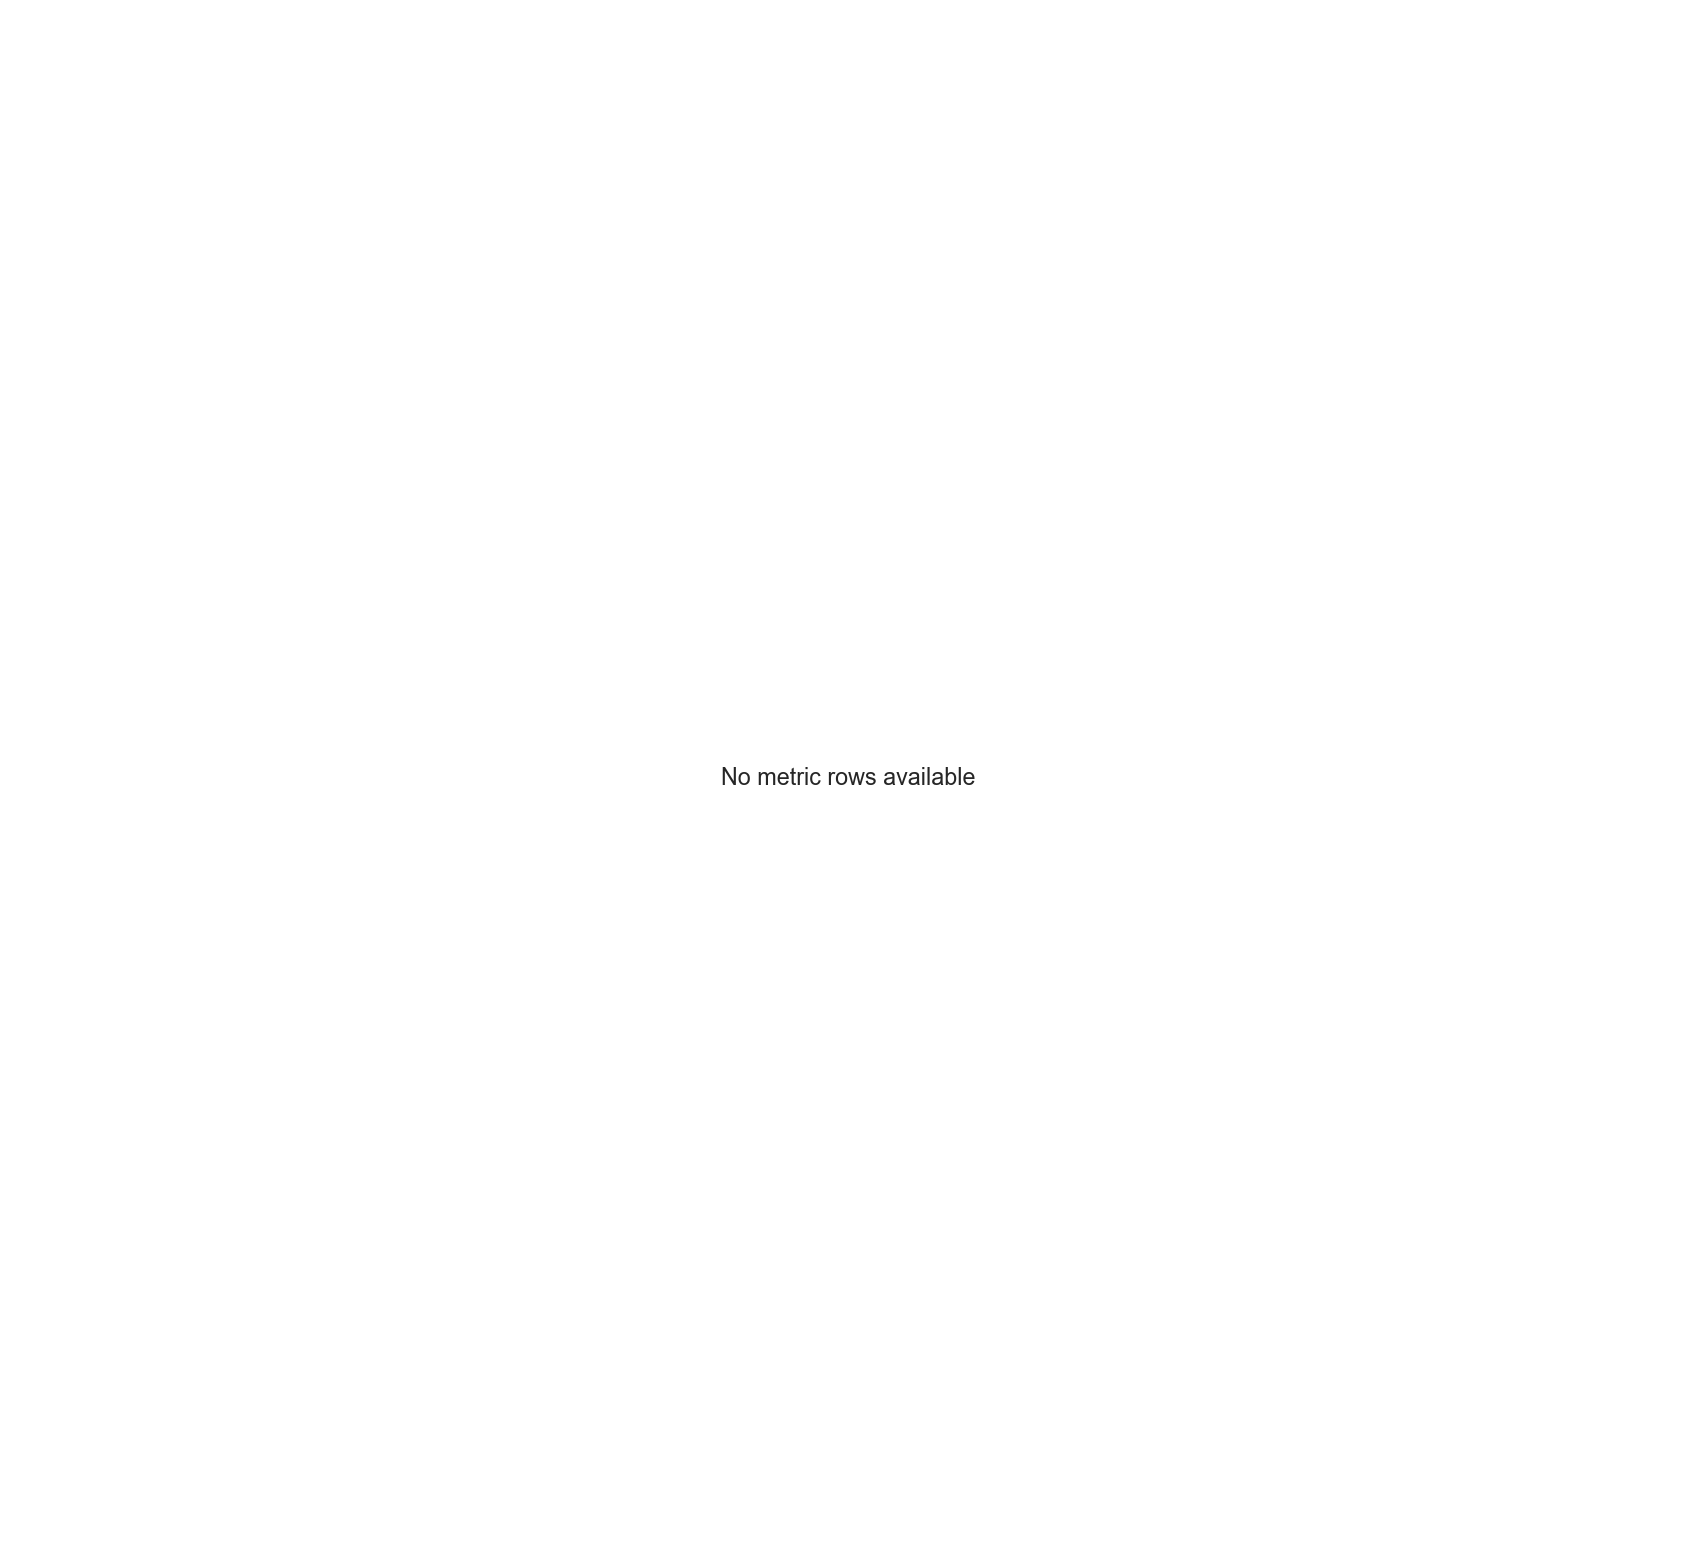

In [14]:
if context_df.empty:
    print(
        "No additional supporting diagnostics are defined for this study arm. "
        "Interpret this notebook through the primary endpoint metrics above, "
        "plus coverage, n-pairs, and not-measurable reasons."
    )
else:
    display(secondary_metric_headline(context_df).round(4))
    fig, ax = plt.subplots(figsize=(12, max(4, 0.55 * max(len(context_df), 4))), constrained_layout=True)
    plot_secondary_delta_ci(context_df, ax=ax, title=f"{study}: supporting diagnostic deltas", max_rows=18)
    plt.show()

## Per-model sensitivity ranking

In [15]:
measured = df[(df["status"] == "ok") & df["delta"].notna() & (df["n_pairs"] > 0)].copy()
ranking = (
    measured.assign(abs_delta=measured["delta"].abs())
    .groupby(["lane", "model"], dropna=False)
    .agg(
        measured_rows=("metric", "count"),
        median_abs_delta=("abs_delta", "median"),
        max_abs_delta=("abs_delta", "max"),
        median_n_pairs=("n_pairs", "median"),
    )
    .reset_index()
    .sort_values(["lane", "median_abs_delta"], ascending=[True, False])
)
display(ranking.round(4))

,lane,model,measured_rows,median_abs_delta,max_abs_delta,median_n_pairs
2,controllability,psyche-r1-local,4,0.0147,0.0286,122.0
3,controllability,psyllm-lmstudio,4,0.0002,0.0103,118.0
4,controllability,qwen3-lmstudio,4,0.0001,0.0005,300.0
1,controllability,piaget-8b-local,4,0.0000,0.0003,294.0
0,controllability,gpt-oss-20b,4,0.0000,0.0000,300.0


## Interpretation

Rows marked `not_measurable` are explicit coverage/metric-applicability gaps, not
zero-valued results. Treat CIs crossing zero as descriptive only. Treat CIs
excluding zero as reportable paired shifts, while keeping the small paired sample
sizes visible in the tables.

{lens["interpretation"]}